In [1]:
# @title Setup & Imports
# @markdown Installing dependencies, importing libraries, and initializing the environment.

# 1. Install Dependencies
print("Installing dependencies...")
!pip install -q monai-generative lpips torch torchvision matplotlib "monai[tqdm]"

# 2. Imports
import os
import shutil
import tempfile
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from google.colab import drive

# MONAI & Generative Imports
from monai import transforms
from monai.config import print_config
from monai.data import DataLoader, Dataset
from monai.utils import first, set_determinism
from torch.cuda.amp import GradScaler, autocast

from generative.inferers import LatentDiffusionInferer
from generative.losses.adversarial_loss import PatchAdversarialLoss
from generative.losses.perceptual import PerceptualLoss
from generative.networks.nets import AutoencoderKL, DiffusionModelUNet, PatchDiscriminator
from generative.networks.schedulers import DDPMScheduler

# 3. Mount Google Drive
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

# 4. Global Settings
set_determinism(42)

# 5. Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# 6. Print Config
print_config()

Installing dependencies...


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda
MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.9.0+cu126
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.24.0+cu126
tqdm version: 4.67.2
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.mo

/usr/local/lib/python3.12/dist-packages/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/usr/local/lib/python3.12/dist-packages/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [2]:
# @title Load & Prepare Dataset
# @markdown Loading processed tumor packs, splitting into train/val, and creating DataLoaders.

# Configuration
data_dir = '/content/drive/MyDrive/Fridge/Latent_Diffusion_Tumor_Synthesis/processed_tumor_packs'
batch_size = 70

# 1. Load and concatenate all tumor packs directly
print("Loading tumor packs...")
pack_files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.pt')])

# Load each pack, keep only MRI channel (0), convert to float, and concatenate
# Result shape: [Total_Images, 1, 240, 240]
all_data = torch.cat([torch.load(f, map_location="cpu")[:, 0:1].float() for f in tqdm(pack_files)], dim=0)

# 2. Split into Train (90%) and Validation (10%)
split_idx = int(len(all_data) * 0.9)
train_tensors, val_tensors = all_data[:split_idx], all_data[split_idx:]

print(f"Total images: {len(all_data)} | Train: {len(train_tensors)} | Val: {len(val_tensors)}")

# 3. Wrap in MONAI Datasets (expects list of dicts)
# We create a list of dictionaries: [{'image': tensor}, ...]
train_ds = Dataset(data=[{"image": img} for img in train_tensors])
val_ds = Dataset(data=[{"image": img} for img in val_tensors])

# 4. Initialize DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

Loading tumor packs...


100%|██████████| 13/13 [00:06<00:00,  2.03it/s]


Total images: 24354 | Train: 21918 | Val: 2436


Fetching a random batch...

--- Data Sanity Check ---
Total Training Images:   21918
Total Validation Images: 2436
Batch Tensor Shape:      torch.Size([70, 1, 240, 240]) (Batch, Channel, Height, Width)
Data Type:               torch.float32
Pixel Value Range:       Min -1.0000 | Max 1.0000
Mean Value:              -0.8491
Std Dev:                 0.3048


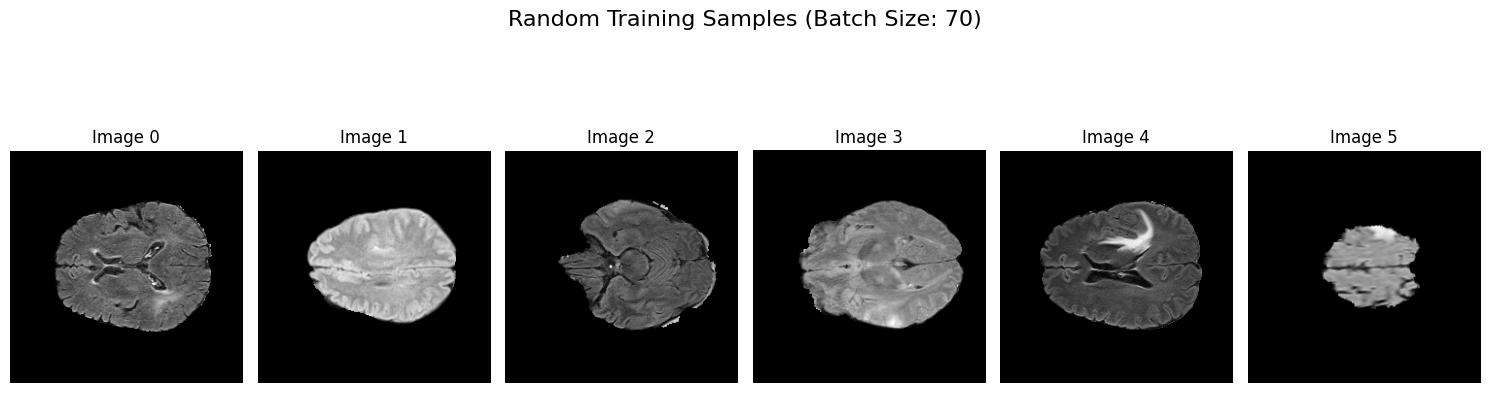

In [3]:
# @title Data Sanity Check & Visualization
# @markdown Visualizing a random batch from the training set and checking data statistics.

import matplotlib.pyplot as plt
import torch
import numpy as np

#Sanity Check & Visualization

# 1. Fetch a single batch from the training loader
print("Fetching a random batch...")
batch = next(iter(train_loader))
images = batch["image"]

# 2. Print Shapes and Statistics
print("\n--- Data Sanity Check ---")
print(f"Total Training Images:   {len(train_ds)}")
print(f"Total Validation Images: {len(val_ds)}")
print(f"Batch Tensor Shape:      {images.shape} (Batch, Channel, Height, Width)")
print(f"Data Type:               {images.dtype}")
print(f"Pixel Value Range:       Min {images.min():.4f} | Max {images.max():.4f}")
print(f"Mean Value:              {images.mean():.4f}")
print(f"Std Dev:                 {images.std():.4f}")

# 3. Visualize a few samples from the batch
num_samples = 6 # @param {type:"integer"}

# Ensure we don't try to plot more images than exist in the batch
actual_samples = min(num_samples, len(images))

fig, axes = plt.subplots(1, actual_samples, figsize=(15, 5))
if actual_samples == 1: axes = [axes] # Handle single subplot case
fig.suptitle(f"Random Training Samples (Batch Size: {len(images)})", fontsize=16)

for i in range(actual_samples):
    # Move to CPU and remove channel dimension for plotting
    img_np = images[i, 0].cpu().numpy()

    axes[i].imshow(img_np, cmap="gray")
    axes[i].set_title(f"Image {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [4]:
# @title Define AutoencoderKL Model
# @markdown Defining the network architecture.

autoencoderkl = AutoencoderKL(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    num_channels=(64, 128, 256),
    latent_channels=3,
    num_res_blocks=2,
    attention_levels=(False, False, True),
    with_encoder_nonlocal_attn=False,
    with_decoder_nonlocal_attn=False,
)
autoencoderkl = autoencoderkl.to(device)

In [5]:
# @title Define Perceptual Loss
# @markdown Initializing LPIPS perceptual loss.

perceptual_loss = PerceptualLoss(spatial_dims=2, network_type="alex")
perceptual_loss.to(device)
perceptual_weight = 0.001

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
# @title Define Discriminator & Adversarial Loss
# @markdown Initializing PatchDiscriminator and GAN loss.

discriminator = PatchDiscriminator(spatial_dims=2, num_layers_d=3, num_channels=64, in_channels=1, out_channels=1)
discriminator = discriminator.to(device)

adv_loss = PatchAdversarialLoss(criterion="least_squares")
adv_weight = 0.01

In [7]:
# @title Define Optimizers
# @markdown Setting up Adam optimizers for Generator and Discriminator.

optimizer_g = torch.optim.Adam(autoencoderkl.parameters(), lr=1e-4)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=5e-4)

# For mixed precision training
scaler_g = torch.amp.GradScaler('cuda')
scaler_d = torch.amp.GradScaler('cuda')

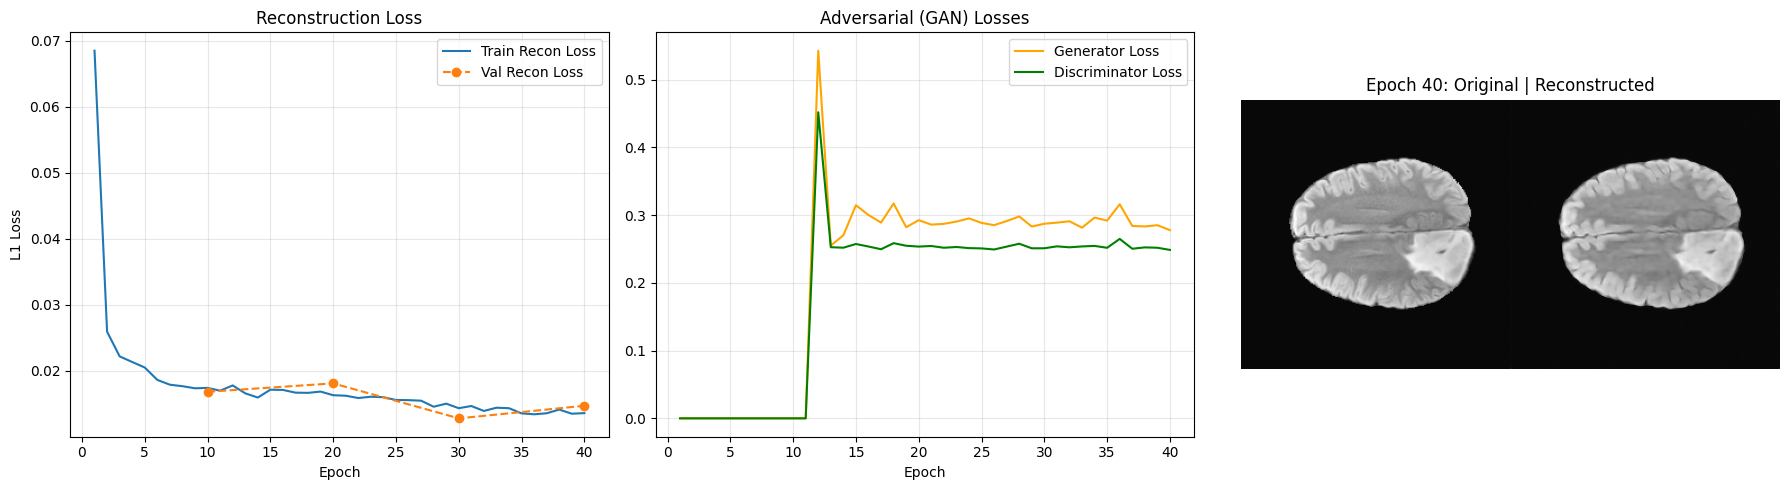

Epoch 40/100 Completed.
Train Recon Loss: 0.0136
Validation Loss: 0.0147 (Best: 0.0128)


Epoch 40:  12%|█        | 39/314 [00:32<03:50,  1.19it/s, recons_loss=0.0133, gen_loss=0.267, disc_loss=0.259]


KeyboardInterrupt: 

In [8]:
# @title Train Autoencoder
# @markdown Training the AutoencoderKL model with reconstruction, perceptual, and adversarial losses.

import matplotlib.pyplot as plt
from IPython.display import clear_output
import os

# Hyperparameters
kl_weight = 1e-6 # @param {type:"number"}
n_epochs = 100 # @param {type:"integer"}
val_interval = 10 # @param {type:"integer"}
autoencoder_warm_up_n_epochs = 10 # @param {type:"integer"}

# Arrays to keep track of losses
epoch_recon_losses = []
epoch_gen_losses = []
epoch_disc_losses = []
val_recon_losses = []
val_epochs = []

# Checkpoint setup
# Saving to Google Drive so checkpoints persist after runtime disconnects
save_dir = "/content/drive/MyDrive/Fridge/Latent_Diffusion_Tumor_Synthesis/checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_val_loss = float('inf')

for epoch in range(n_epochs):
    autoencoderkl.train()
    discriminator.train()
    epoch_loss = 0
    gen_epoch_loss = 0
    disc_epoch_loss = 0
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=110)
    progress_bar.set_description(f"Epoch {epoch}")

    for step, batch in progress_bar:
        images = batch["image"].to(device)
        optimizer_g.zero_grad(set_to_none=True)

        with autocast(enabled=True):
            reconstruction, z_mu, z_sigma = autoencoderkl(images)

            recons_loss = F.l1_loss(reconstruction.float(), images.float())
            p_loss = perceptual_loss(reconstruction.float(), images.float())
            kl_loss = 0.5 * torch.sum(z_mu.pow(2) + z_sigma.pow(2) - torch.log(z_sigma.pow(2)) - 1, dim=[1, 2, 3])
            kl_loss = torch.sum(kl_loss) / kl_loss.shape[0]
            loss_g = recons_loss + (kl_weight * kl_loss) + (perceptual_weight * p_loss)

            if epoch > autoencoder_warm_up_n_epochs:
                logits_fake = discriminator(reconstruction.contiguous().float())[-1]
                generator_loss = adv_loss(logits_fake, target_is_real=True, for_discriminator=False)
                loss_g += adv_weight * generator_loss

        scaler_g.scale(loss_g).backward()
        scaler_g.step(optimizer_g)
        scaler_g.update()

        if epoch > autoencoder_warm_up_n_epochs:
            with autocast(enabled=True):
                optimizer_d.zero_grad(set_to_none=True)

                logits_fake = discriminator(reconstruction.contiguous().detach())[-1]
                loss_d_fake = adv_loss(logits_fake, target_is_real=False, for_discriminator=True)
                logits_real = discriminator(images.contiguous().detach())[-1]
                loss_d_real = adv_loss(logits_real, target_is_real=True, for_discriminator=True)
                discriminator_loss = (loss_d_fake + loss_d_real) * 0.5

                loss_d = adv_weight * discriminator_loss

            scaler_d.scale(loss_d).backward()
            scaler_d.step(optimizer_d)
            scaler_d.update()

        epoch_loss += recons_loss.item()
        if epoch > autoencoder_warm_up_n_epochs:
            gen_epoch_loss += generator_loss.item()
            disc_epoch_loss += discriminator_loss.item()

        progress_bar.set_postfix(
            {
                "recons_loss": epoch_loss / (step + 1),
                "gen_loss": gen_epoch_loss / (step + 1),
                "disc_loss": disc_epoch_loss / (step + 1),
            }
        )

    # Record training losses
    epoch_recon_losses.append(epoch_loss / (step + 1))
    epoch_gen_losses.append(gen_epoch_loss / (step + 1))
    epoch_disc_losses.append(disc_epoch_loss / (step + 1))

    # Validation Loop
    if (epoch + 1) % val_interval == 0:
        autoencoderkl.eval()
        val_loss = 0
        with torch.no_grad():
            for val_step, batch in enumerate(val_loader, start=1):
                images = batch["image"].to(device)
                with autocast(enabled=True):
                    reconstruction, z_mu, z_sigma = autoencoderkl(images)
                    recons_loss = F.l1_loss(images.float(), reconstruction.float())
                val_loss += recons_loss.item()

        val_loss /= val_step
        val_recon_losses.append(val_loss)
        val_epochs.append(epoch + 1)

        # Checkpoint: Save Best Model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(autoencoderkl.state_dict(), os.path.join(save_dir, "best_autoencoder.pth"))
            print(f"\n>>> New Best Model saved at Epoch {epoch+1} (Val Loss: {val_loss:.4f})")

    # Checkpoint: Save Latest Model (Every Epoch)
    torch.save({
        'epoch': epoch,
        'model_state_dict': autoencoderkl.state_dict(),
        'optimizer_g_state_dict': optimizer_g.state_dict(),
        'optimizer_d_state_dict': optimizer_d.state_dict(),
        'loss': epoch_loss,
        'best_val_loss': best_val_loss
    }, os.path.join(save_dir, "latest_checkpoint.pth"))

    # --- Dynamic Visualization & Plotting ---
    clear_output(wait=True)

    # Generate a visual sample for plotting
    autoencoderkl.eval()
    with torch.no_grad():
        val_batch = first(val_loader)
        val_img = val_batch["image"][0:1].to(device)
        with autocast(enabled=True):
            val_recon, _, _ = autoencoderkl(val_img)

    # Setup Plots
    plt.figure(figsize=(18, 5))

    # Plot 1: Reconstruction Losses (Train vs Val)
    plt.subplot(1, 3, 1)
    plt.plot(range(1, epoch + 2), epoch_recon_losses, label='Train Recon Loss')
    if len(val_recon_losses) > 0:
        plt.plot(val_epochs, val_recon_losses, label='Val Recon Loss', marker='o', linestyle='--')
    plt.title("Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("L1 Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: GAN Losses (Generator vs Discriminator)
    plt.subplot(1, 3, 2)
    # Only plot if GAN training has started
    if epoch > autoencoder_warm_up_n_epochs:
        plt.plot(range(1, epoch + 2), epoch_gen_losses, label='Generator Loss', color='orange')
        plt.plot(range(1, epoch + 2), epoch_disc_losses, label='Discriminator Loss', color='green')
        plt.title("Adversarial (GAN) Losses")
        plt.xlabel("Epoch")
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.title("Adversarial Training Not Started")
        plt.text(0.5, 0.5, "Warm-up Phase", ha='center', va='center')

    # Plot 3: Image Comparison (Original vs Recon)
    plt.subplot(1, 3, 3)
    orig_np = val_img[0, 0].cpu().numpy()
    recon_np = val_recon[0, 0].cpu().float().numpy()
    combined = np.concatenate((orig_np, recon_np), axis=1)
    plt.imshow(combined, cmap="gray")
    plt.title(f"Epoch {epoch+1}: Original | Reconstructed")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Print textual status after plot
    print(f"Epoch {epoch+1}/{n_epochs} Completed.")
    print(f"Train Recon Loss: {epoch_recon_losses[-1]:.4f}")
    if len(val_recon_losses) > 0 and (epoch + 1) == val_epochs[-1]:
        print(f"Validation Loss: {val_recon_losses[-1]:.4f} (Best: {best_val_loss:.4f})")

progress_bar.close()
del discriminator
del perceptual_loss
torch.cuda.empty_cache()

In [13]:
import os
import torch
import numpy as np

# 1. Define Output Directory
save_dir = "/content/drive/MyDrive/Fridge/Latent_Diffusion_Tumor_Synthesis/trained_autoencoder/"
os.makedirs(save_dir, exist_ok=True)

# 2. Save Model Checkpoint
# We use the correct model variable name: 'autoencoderkl'
checkpoint_path = os.path.join(save_dir, "autoencoder_epoch_40_manual.pth")
torch.save(autoencoderkl.state_dict(), checkpoint_path)
print(f"Model checkpoint saved to: {checkpoint_path}")

# 3. Save Loss History
# We use the correct loss list names from the training loop
try:
    np.save(os.path.join(save_dir, "train_loss_history.npy"), np.array(epoch_recon_losses))
    np.save(os.path.join(save_dir, "val_loss_history.npy"), np.array(val_recon_losses))
    print("Training and validation loss history saved successfully.")
except NameError as e:
    print(f"Warning: Could not save loss history. Error: {e}")

Model checkpoint saved to: /content/drive/MyDrive/Fridge/Latent_Diffusion_Tumor_Synthesis/trained_autoencoder/autoencoder_epoch_40_manual.pth
Training and validation loss history saved successfully.
